In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [73]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

idandalal_thumbnail_path = kagglehub.dataset_download('idandalal/thumbnail')
raedaddala_top_500_600_movies_of_each_year_from_1960_to_2024_path = kagglehub.dataset_download('raedaddala/top-500-600-movies-of-each-year-from-1960-to-2024')

print('Data source import complete.')
print(f'Thumbnail dataset path: {idandalal_thumbnail_path}')
print(f'Movies dataset path: {raedaddala_top_500_600_movies_of_each_year_from_1960_to_2024_path}')

Data source import complete.
Thumbnail dataset path: /root/.cache/kagglehub/datasets/idandalal/thumbnail/versions/1
Movies dataset path: /kaggle/input/top-500-600-movies-of-each-year-from-1960-to-2024


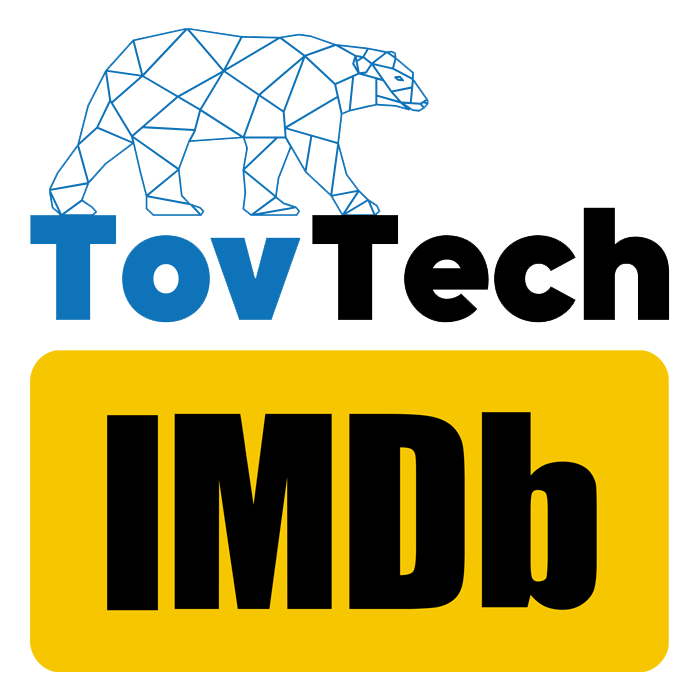

In [74]:
# Cover image
from IPython.display import Image
display(Image(filename='/root/.cache/kagglehub/datasets/idandalal/thumbnail/versions/1/COVER.png'))

# 🎬 The Director’s Compass
This project answers a single, commercially focused question: **does a director's genre versatility predict their success?**

From the perspective of a talent agent advising a major studio, this analysis uses a complex IMDb dataset to define and measure director success.

The approach blends audience **quality** (ratings) and **reach** (votes) into a single metric.

By mapping this success score against genre versatility, I develop a practical framework—The Director's Compass—to identify and categorize talent into four actionable archetypes.

*<u>Next:</u> import essential libraries, configure the environment, and define helper functions.*

In [75]:
# Imports, constants, theme, and helpers
import ast
import math
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display, HTML, Markdown
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Table display preferences
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 160)

# Visual constants
WIDTH = 1000
HEIGHT_MED = 600
HEIGHT_TALL = 800
IMDb_YELLOW = "#F5C518"

# Global Plotly defaults - force dark for all figures
px.defaults.template = "plotly_dark"

def dark(fig, title=None, height=HEIGHT_MED, width=WIDTH):
    """Apply uniform dark styling and fixed dimensions to a Plotly figure."""
    fig.update_layout(
        title=title,
        width=width,
        height=height,
        template="plotly_dark",
        paper_bgcolor="#000000",
        plot_bgcolor="#000000",
        font=dict(color="#FFFFFF"),
        margin=dict(l=40, r=30, t=70, b=40),)
    return fig

def pv(message: str):
    """Yellow-accent verification box for dynamic facts. Use <span style='color:{IMDb_YELLOW};font-weight:bold'>...</span> for variables."""
    box = ("<div style='background:#000;color:#fff;padding:12px 16px;margin:10px 0;"
        f"border-left:10px solid {IMDb_YELLOW};font-size:15px;line-height:1.15;'>"
        + message + "</div>")
    display(HTML(box))

def sty(df: pd.DataFrame, formats: dict | None = None):
    """Consistent dark-styled DataFrame."""
    formats = formats or {}
    return (df.style
          .format(formats)
          .hide(axis="index")
          .set_table_styles([
              {'selector': 'th', 'props': [('text-align','center'),
                                           ('background-color','#111'), ('color','#fff'),
                                           ('padding','6px 8px')]},
              {'selector': 'td', 'props': [('background-color','#0A0A0A'), ('color','#fff'),
                                           ('border-color','#222'), ('padding','6px 8px')]},
              {'selector': 'tr:nth-child(even)', 'props': [('background-color','#0F0F0F')]},
              {'selector': 'tr:hover', 'props': [('background-color','#1A1A1A')]}])
          .set_properties(**{'border-color':'#222'}))

def to_votes(x):
    """Convert '2.1K' or '1.5M' strings to numeric votes; pass numeric through."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).strip().upper()
    try:
        if s.endswith("K"):
            return float(s[:-1]) * 1_000
        if s.endswith("M"):
            return float(s[:-1]) * 1_000_000
        return float(s.replace(",", ""))
    except Exception:
        return np.nan

def parse_duration_minutes(s):
    """Parse '1h 37m' or '97 min' or numeric minutes into minutes."""
    if pd.isna(s):
        return np.nan
    if isinstance(s, (int, float)) and not math.isnan(s):
        return float(s)
    text = str(s).lower()
    h = m = 0
    if "h" in text:
        try:
            h = float(text.split("h")[0].strip())
        except Exception:
            h = 0
    if "m" in text:
        try:
            right = text.split("h")[-1] if "h" in text else text
            m = float(right.replace("min", "").replace("m", "").strip())
        except Exception:
            m = 0
    if "min" in text and "h" not in text and "m" not in text:
        try:
            m = float(text.replace("min", "").strip())
        except Exception:
            m = 0
    total = h * 60 + m
    return total if total > 0 else np.nan

def parse_list(field):
    """Parse JSON-like list strings into Python lists; handle plain comma strings and None."""
    if pd.isna(field):
        return []
    val = field
    if isinstance(val, list):
        return [str(v).strip() for v in val if str(v).strip()]
    s = str(val).strip()
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass
    return [i.strip().strip("'\"") for i in s.split(",") if i.strip().strip("'\"")]

# Archetype color map for visuals
ARCH_COLORS = {"The Masters": "#10B981",
               "The Specialists": "#A855F7",
               "The Craftsmen": "#60A5FA",
               "The Explorers": "#F59E0B",}

# Environment verification: confirm constants and theme are live
pv(f"Theme: <span style='color:{IMDb_YELLOW};font-weight:bold'>plotly_dark</span>. "
   f"Fixed width <span style='color:{IMDb_YELLOW};font-weight:bold'>" + str(WIDTH) + " px</span> width. "
   f"IMDb accent color: <span style='color:{IMDb_YELLOW};font-weight:bold'>" + IMDb_YELLOW + "</span>")

## 1. Ground Truth: Loading and Verifying the IMDb Dataset
The analysis begins by loading the dataset and performing essential integrity checks.

This ensures our source data is free of duplicates and that we have a clear picture of its scope and any missing values.

The key columns for this analysis include:
- **Identification & Context:** `id`, `title`, `year`
- **Success Metrics:** `rating` (quality), `votes` (reach)
- **Versatility Metric:** `genres`
- **Attribution Axis:** `directors`

These initial steps are critical for grounding all downstream metrics in verified counts and avoiding skewed comparisons later.

*<u>Next:</u> examine the distribution of our primary success metric - audience ratings.*

In [76]:
# Load data from the project path
df_raw = pd.read_csv('/root/.cache/kagglehub/datasets/raedaddala/top-500-600-movies-of-each-year-from-1960-to-2024/versions/7/final_dataset.csv')

# Parse release date and year
df_raw["release_date"] = pd.to_datetime(df_raw.get("release_date", pd.NaT), errors="coerce")
df_raw["year"] = df_raw["release_date"].dt.year

pv(f"Loaded dataset with <span style='color:{IMDb_YELLOW};font-weight:bold'>{len(df_raw):,}</span> rows and "
   f"<span style='color:{IMDb_YELLOW};font-weight:bold'>{len(df_raw.columns)}</span> columns from "
   f"<span style='color:{IMDb_YELLOW};font-weight:bold'>{int(df_raw['year'].min()) if df_raw['year'].notna().any() else 'n/a'}</span>"
   f" to <span style='color:{IMDb_YELLOW};font-weight:bold'>{int(df_raw['year'].max()) if df_raw['year'].notna().any() else 'n/a'}</span>")

# Compact missingness snapshot for key columns we actually use
key_cols = [c for c in ["rating","votes","duration","genres","directors","release_date"] if c in df_raw.columns]
miss = df_raw[key_cols].isna().mean().rename("missing_pct").mul(100).round(1).reset_index().rename(columns={"index":"column"})
display(sty(miss, formats={"missing_pct":"{:.1f}%"}))

# Duplicates check and safe drop on 'id'
dup_ct = int(df_raw.duplicated(subset=["id"]).sum()) if "id" in df_raw.columns else 0
if dup_ct > 0 and "id" in df_raw.columns:
    df_raw = df_raw.drop_duplicates(subset=["id"]).reset_index(drop=True)
pv(f"Duplicate ids detected: <span style='color:{IMDb_YELLOW};font-weight:bold'>{dup_ct:,}</span>. "
   f"Rows remaining after drop: <span style='color:{IMDb_YELLOW};font-weight:bold'>{len(df_raw):,}</span>")

column,missing_pct
rating,6.4%
votes,6.4%
duration,3.3%
genres,1.2%
directors,0.1%
release_date,0.0%


### Raw Data Preview
I show a compact table with the core fields we actually analyze so we can confirm shapes and values before any transformation.

*<u>Next:</u> inspect the rating distribution to understand central tendency and spread.*

In [77]:
# Compact preview
preview_cols = ["id","title","year","duration","rating","votes","genres","directors"]
display(sty(df_raw.head(5)[[c for c in preview_cols if c in df_raw.columns]], formats={"rating": "{:.1f}"}))

id,title,year,duration,rating,votes,genres,directors
tt10208198,"The Gangster, the Cop, the Devil",2019,1h 49m,7.0,28K,"['True Crime', 'Action', 'Crime', 'Thriller']",['Lee Won-tae']
tt3960412,Popstar: Never Stop Never Stopping,2016,1h 27m,6.7,71K,"['Mockumentary', 'Raunchy Comedy', 'Comedy', 'Drama', 'Music', 'Musical']","['Akiva Schaffer', 'Jorma Taccone']"
tt1001508,He's Just Not That Into You,2009,2h 9m,6.4,188K,"['Feel-Good Romance', 'Romantic Comedy', 'Comedy', 'Drama', 'Romance']",['Ken Kwapis']
tt0038303,Anna and the King of Siam,1946,2h 8m,7.0,2.8K,"['Period Drama', 'Biography', 'Drama', 'Romance']",['John Cromwell']
tt1401152,Unknown,2011,1h 53m,6.8,273K,"['Action', 'Mystery', 'Thriller']",['Jaume Collet-Serra']


## 2. Finding the Signal: Audience Ratings Cluster Above Average
**Claim:** The distribution of audience ratings is not uniform. It is left-skewed, with most films clustering in the 6.0 to 7.5 range.

This insight is crucial for setting realistic performance benchmarks.

**Evidence:** The histogram shows that while ratings span from 1.0 to 10.0, the median rating is **6.3**.

The densest concentration of films receives ratings significantly above the scale's midpoint of 5.0.

**Interpretation:** The long left tail of lower-rated films indicates a clear segment of underperformers.

More importantly, the high concentration in the upper range suggests that using the median is a robust way to compare films, as it won't be easily skewed by the poorly-rated outliers.

*<u>Next:</u> normalize the messy, real-world data into a format suitable for analysis.*

In [78]:
# Rating Distribution (continuous color; low = red, high = green)
if "rating" in df_raw.columns:
    import numpy as np
    # Define bins to align with 0.25 increments on the x-axis
    min_rating = df_raw["rating"].min()
    max_rating = df_raw["rating"].max()
    bins = np.arange(min_rating, max_rating + 0.25, 0.25)
    counts, edges = np.histogram(df_raw["rating"].dropna(), bins=bins)
    mids = 0.5 * (edges[1:] + edges[:-1])
    hist_df = pd.DataFrame({"bin_mid": mids, "count": counts})

    # Calculate percentage of total count
    total_count = hist_df["count"].sum()
    hist_df["percentage"] = (hist_df["count"] / total_count) * 100

    fig = px.bar(hist_df, x="bin_mid", y="count", color="bin_mid", color_continuous_scale="RdYlGn")
    fig.update_traces(hovertemplate="Rating %{x:.2f}<br>Count %{y:,}<br>Percentage %{customdata:.1f}%<extra></extra>", customdata=hist_df["percentage"])
    fig.update_xaxes(title="Rating", tickmode='linear', tick0=0, dtick=0.5); fig.update_yaxes(title="Count", tickformat = ",.0f", range=[1, 7500])
    fig = dark(fig, title="Insight: Audience Ratings Skew Positively, Centered at 6.3", height=HEIGHT_MED, width=WIDTH)
    fig.update_coloraxes(colorbar_title="Rating", showscale=False)

    # Add text annotations for percentages above bars
    fig.update_traces(text=hist_df["percentage"].apply(lambda x: f"{x:.1f}%" if x > 0 else ""),
                      textposition="outside",
                      textfont=dict(size=8)) # Adjusted font size for 3 characters

    # Add a shaded area for the "long left tail" (ratings below median)
    fig.add_shape(type="rect",
                  x0=df_raw["rating"].min(), y0=0,
                  x1=6.2, y1=6878,
                  fillcolor="lightgrey", opacity=0.2, layer="below", line_width=0)

    # Add annotation for the highlighted tail
    fig.add_annotation(
        x=df_raw["rating"].median() * 0.5,  # Position inside the shaded area
        y=counts.max() * 0.89,              # Position near the top of the bars
        text="<b>Long Left Tail</b><br>This area shows the significant<br>number of films with below-median<br>ratings.",
        showarrow=False,
        align="left",
        font=dict(color="white", size=12),
        bgcolor="rgba(0,0,0,0.5)",
        borderpad=4)

    fig.show()

## 3. The Foundation: Normalizing Data for Accurate Analysis
Before analyzing director performance, the raw data must be cleaned, normalized, and restructured.

This process involves three steps:
- standardizing data types
- reshaping the data to be director-centric
- applying a visibility filter.

*<u>Next:</u> convert messy text fields into clean, usable numeric and list formats.*

In [79]:
# Copy and normalize core fields
df = df_raw.copy()

# Votes and duration normalization
df["votes_n"] = df.get("votes").apply(to_votes) if "votes" in df.columns else np.nan
df["duration_minutes"] = df.get("duration").apply(parse_duration_minutes) if "duration" in df.columns else np.nan

# Parse key list fields if present
for col in ["genres", "directors", "writers", "stars"]:
    if col in df.columns:
        df[col] = df[col].apply(parse_list)

# Quick verification of parsing success
n_votes_parsed = int(df["votes_n"].notna().sum()) if "votes_n" in df.columns else 0
n_dur_parsed = int(df["duration_minutes"].notna().sum()) if "duration_minutes" in df.columns else 0
pv(f"Numeric conversions - votes parsed: <span style='color:{IMDb_YELLOW};font-weight:bold'>{n_votes_parsed:,}</span>, "
   f"duration parsed: <span style='color:{IMDb_YELLOW};font-weight:bold'>{n_dur_parsed:,}</span>")

# Preview the transformations
show_cols = [c for c in ["title", "votes", "votes_n", "duration", "duration_minutes"] if c in df.columns]
if show_cols:
    display(sty(df.head(8)[show_cols], formats={"votes_n": "{:,.0f}", "duration_minutes": "{:,.0f}"}))

title,votes,votes_n,duration,duration_minutes
"The Gangster, the Cop, the Devil",28K,"28,000",1h 49m,109
Popstar: Never Stop Never Stopping,71K,"71,000",1h 27m,87
He's Just Not That Into You,188K,"188,000",2h 9m,129
Anna and the King of Siam,2.8K,"2,800",2h 8m,128
Unknown,273K,"273,000",1h 53m,113
Manhattan Parade,177,177,1h 15m,75
Boyhood,139,139,1h 51m,111
Anakan mo ako,63,63,1h 39m,99


### 3-A: Reshaping Data to a Director-Centric View
Now we transform the dataset from a film-centric view to a director-centric one.

This allows us to attribute the performance of each film to each of its individual directors.

In [80]:
# Explode directors for per-director analysis
df_director = df.explode("directors").rename(columns={"directors": "director"})
df_director = df_director[~df_director["director"].isna() & (df_director["director"] != "")]

# Preview the exploded DataFrame to show the new structure
display(Markdown("### Director-Centric Dataset Preview"))
# Reset the index before applying the style function
display(sty(df_director[["title", "director", "rating"]].head(6).reset_index(drop=True), formats={"rating": "{:.1f}"}))

### Director-Centric Dataset Preview

title,director,rating
"The Gangster, the Cop, the Devil",Lee Won-tae,7.0
Popstar: Never Stop Never Stopping,Akiva Schaffer,6.7
Popstar: Never Stop Never Stopping,Jorma Taccone,6.7
He's Just Not That Into You,Ken Kwapis,6.4
Anna and the King of Siam,John Cromwell,7.0
Unknown,Jaume Collet-Serra,6.8


### 3-B: Applying a Commercial Viability Filter
To ensure our analysis is commercially relevant, we will filter the dataset to include only "visible films"—those that have achieved a minimum threshold of audience engagement.

We define this as any film with at least 1,000 votes.

In [81]:
# Create the final, filtered DataFrame for all subsequent analysis
films_visible = df_director[df_director["votes_n"] >= 1_000].copy()

# Add a final verification message
pv(f"Created final analysis set with <span style='color:{IMDb_YELLOW};font-weight:bold'>"
   f"{len(films_visible):,}</span> film-director entries (from films with >= 1,000 votes).")

## 3-C: Final Data Checkpoint - Runtimes are Commercially Sound
**Claim:** Before analyzing directors, we must standardize our data.

This involves cleaning numeric fields, parsing text lists, and reshaping the data to be director-centric.

A sanity check on film runtimes confirms our dataset aligns with commercial standards.

**Evidence:** We successfully converted over 59,000 vote entries and 61,000 duration entries into clean numeric formats.

The runtime violin plot shows that most films cluster tightly between 85 and 120 minutes, with a median of 95 minutes.

Finally, we reshaped the data and filtered it to a final set of **28,883** film-director entries for films with over 1,000 votes.

**Interpretation:** These transformations create a reliable foundation for the entire analysis.

The standardized runtimes confirm we're analyzing a commercially conventional set of films, and the director-centric structure allows us to attribute success accurately.

*<u>Next:</u> step is to establish market benchmarks by analyzing the most popular genres.*

In [82]:
# Runtime Distribution as violin with 99th percentile cap to avoid scale crush by outliers
if "duration_minutes" in df.columns:
    y_lo = 0
    y_hi = float(df["duration_minutes"].quantile(0.99))
    n_out = int((df["duration_minutes"] > y_hi).sum())
    fig = px.violin(df, y="duration_minutes", box=True, points=False)
    fig.update_traces(fillcolor=IMDb_YELLOW, line_color=IMDb_YELLOW, opacity=0.55, selector=dict(type="violin"))
    fig.update_yaxes(title="Duration (minutes)", range=[y_lo, y_hi])
    fig = dark(fig, title="Sanity Check: Film Runtimes Align with Commercial Norms (Median ~95 min)", height=HEIGHT_MED, width=WIDTH)

    # Add lines and shaded area for the commercial norm (85-120 minutes)
    commercial_norm_min = 85
    commercial_norm_max = 120
    fig.add_shape(type="line", x0=-0.5, y0=commercial_norm_min, x1=0.5, y1=commercial_norm_min,
                  line=dict(color="lightgrey", width=2, dash="dot"))
    fig.add_shape(type="line", x0=-0.5, y0=commercial_norm_max, x1=0.5, y1=commercial_norm_max,
                  line=dict(color="lightgrey", width=2, dash="dot"))
    fig.add_shape(type="rect", x0=-0.5, y0=commercial_norm_min, x1=0.5, y1=commercial_norm_max,
                  fillcolor="lightgrey", opacity=0.2, layer="below", line_width=0)


    fig.add_annotation(
        text=f"Capped at 99th percentile (~{y_hi:.0f} min). Hidden outliers above cap: {n_out:,}",
        x=0.5, xref="paper", y=1.05, yref="paper", showarrow=False)

    # Add annotation for the commercial norm
    fig.add_annotation(
        x=0, y=102.5,  # Vertically centered in the 85-120 min range
        text="<b>Commercial Norm (85-120 min)</b><br>The dense concentration of films here<br>validates the dataset's relevance.",
        showarrow=False,
        align="center",
        font=dict(color="white", size=12),
        bgcolor="rgba(0,0,0,0.5)",
        borderpad=4)

fig.show()

## 4. The Market Landscape: Deconstructing Genre Performance
**Claim:** Genres are not created equal - some are produced more often, while others command higher ratings or broader audience reach.

Understanding this landscape is key to fairly judging a director's success within a specific market.

**Evidence:** The charts show that **Drama** and **Comedy** are the most produced genres.

However, high-reach genres like **Adventure** and **Action** attract a significantly higher median number of votes (11k and 10k, respectively).

Meanwhile, some high-volume genres like **Horror** have a lower median rating (5.7), establishing a different performance baseline.

**Interpretation:** These metrics provide our market context.

A 6.7 rating in Drama is a solid performance, but a 6.7 in Horror would be a category-leading achievement.

This framework allows us to distinguish a director's skill from a genre's inherent market appeal.

*<u>Next:</u> measuring individual director performance and testing our central hypothesis.*

In [90]:
# Explode genres into long format
if "genres" not in df.columns:
    raise ValueError("Expected 'genres' column was not found in the dataset.")
df_genre = films_visible.explode("genres").rename(columns={"genres": "genre"})
df_genre = df_genre[~df_genre["genre"].isna() & (df_genre["genre"] != "")]

# Aggregate top 10 genres by film count
genre_stats = (df_genre.groupby("genre", as_index=False)
               .agg(film_count=("id", "nunique"),
                    avg_rating=("rating", "median"),
                    avg_votes=("votes_n", "median"))
               .sort_values("film_count", ascending=False)
               .head(10)
               .reset_index(drop=True))

# Plot - triple bar: consistent per-genre colors across all three subplots
from plotly.colors import qualitative

palette = px.colors.qualitative.Vivid  # stable, high-contrast set
genre_color = {g: palette[i % len(palette)] for i, g in enumerate(genre_stats["genre"])}

fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True,
    row_heights=[0.35,0.30,0.35],
    vertical_spacing=0.08,
    subplot_titles=("Output - top 10 genres by film count",
                    "Median rating - audience quality benchmark",
                    "Median votes - audience reach benchmark"))

# Precompute the color array once and reuse to keep colors identical across rows
colors = [genre_color[g] for g in genre_stats["genre"]]

# Row 1: output
fig.add_trace(go.Bar(x=genre_stats["genre"],
                     y=genre_stats["film_count"],
                     marker=dict(color=colors),
                     name="Films",
                     text=genre_stats["film_count"].apply(lambda x: f"{x:,}"),
                     textposition="inside",
                     customdata=genre_stats["film_count"] / genre_stats["film_count"].sum() * 100,
                     hovertemplate="<b>%{x}</b><br>Film Count: %{y:,}<br>Share of Top 10: %{customdata:.1f}%<extra></extra>"),
                     row=1, col=1)

# Row 2: rating
fig.add_trace(go.Bar(x=genre_stats["genre"],
                     y=genre_stats["avg_rating"],
                     marker=dict(color=colors),
                     name="Rating",
                     text=genre_stats["avg_rating"].round(1),
                     textposition="inside",
                     customdata=genre_stats["film_count"],
                     hovertemplate="<b>%{x}</b><br>Median Rating: %{y:.2f}<br>Based on: %{customdata:,} films<extra></extra>"),
                     row=2, col=1)

# Row 3: votes
fig.add_trace(go.Bar(x=genre_stats["genre"],
                     y=genre_stats["avg_votes"],
                     marker=dict(color=colors),
                     name="Votes",
                     text=(genre_stats["avg_votes"]/1000).round(0).astype(int).astype(str) + 'k',
                     textposition="inside",
                     customdata=genre_stats["avg_rating"],
                     hovertemplate="<b>%{x}</b><br>Median Votes: %{y:,.0f}<br>Median Rating: %{customdata:.2f}<extra></extra>"),
                     row=3, col=1)


fig.update_yaxes(title_text="Films", row=1, col=1)
fig.update_yaxes(title_text="Rating", row=2, col=1)
fig.update_yaxes(title_text="Votes", row=3, col=1)

# Customize y-axis scales
fig.update_yaxes(range=[0, 16000], row=1, col=1)
fig.update_yaxes(range=[5.5, 6.8], row=2, col=1)
fig.update_yaxes(range=[4000, 11500], row=3, col=1)


fig.update_layout(showlegend=False)
fig = dark(fig, title="Market Context: Drama & Comedy Dominate Output, but Adventure & Thriller Drive Reach", height=HEIGHT_TALL, width=WIDTH)
fig.show()

# Companion table
display(sty(genre_stats, formats={"film_count":"{:,.0f}","avg_rating":"{:.1f}","avg_votes":"{:,.0f}"}))

genre,film_count,avg_rating,avg_votes
Drama,"15,737",6.7,"5,600"
Comedy,"9,067",6.4,"6,700"
Romance,"6,456",6.6,"5,200"
Thriller,"6,394",6.3,"9,800"
Crime,"4,782",6.6,"7,300"
Action,"4,625",6.3,"10,000"
Horror,"3,507",5.7,"5,600"
Adventure,"3,461",6.5,"11,000"
Mystery,"2,934",6.4,"8,100"
Sci-Fi,"2,282",5.9,"9,200"


## 5. The Analytical Engine: Engineering a Director Success Score
 **Claim:** To objectively measure a director's performance, a simple average is insufficient.

 A composite `success_score` is necessary, blending both the critical acclaim (rating) and commercial reach (votes) of their films into a single, standardized metric.

**Evidence:** The methodology involves three key steps:
1. <u>Aggregate Performance:</u> We first calculate each director's mean rating and mean votes across their qualifying films.
2. <u>Rank and Standardize:</u> To compare directors fairly, we convert these raw averages into percentile ranks (`rating_pct`, `votes_pct`). This shows how a director performs relative to all other directors in the dataset.
 3. <u>Calculate the Weighted Score:</u> We combine these percentiles into a final `success_score` using a **65/35 weighting**, prioritizing audience quality (rating) while still rewarding broad commercial reach (votes).

 **Interpretation:** This engineered score provides a single, robust metric for success.

 It moves beyond simple averages and creates a standardized measure that accounts for the vastly different scales of ratings and votes.

 This allows for a direct, apples-to-apples comparison between any two directors in our cohort.

*<u>Next:</u> we will execute these calculations to build our final director dataset, which is the foundation for the Compass plot.*

In [84]:
# Director-level features on a visibility-filtered cohort
# 1) Filter for visible films (at least 1,000 votes)
# We start with the main 'df' which has clean lists and numbers
df_director = df.explode("directors").rename(columns={"directors": "director"})
df_director = df_director[~df_director["director"].isna() & (df_director["director"] != "")]
films_visible = df_director[df_director["votes_n"] >= 1_000].copy()

# 2) First aggregation: Calculate film count and average scores per director
agg_main = (films_visible.groupby("director", as_index=False)
            .agg(film_count=("id", "nunique"),
                 avg_rating=("rating", "mean"),
                 avg_votes=("votes_n", "mean")))

# 3) Second aggregation: Explode genres from the visible set to calculate diversity
df_genre_exploded = films_visible.explode("genres").rename(columns={"genres": "genre"})
agg_diversity = (df_genre_exploded.groupby("director", as_index=False)
                 .agg(genre_diversity=("genre", "nunique")))

# 4) Merge the two aggregated datasets together on the director's name
agg = pd.merge(agg_main, agg_diversity, on="director")

# 5) Keep directors with repeatability - three or more visible films
directors_set = agg[agg["film_count"] >= 3].reset_index(drop=True)

# Versatility and success construction
directors_set["versatility_score"] = directors_set["genre_diversity"] / directors_set["film_count"].clip(upper=20)
directors_set["rating_pct"] = directors_set["avg_rating"].rank(pct=True) * 100
directors_set["votes_pct"] = directors_set["avg_votes"].rank(pct=True) * 100
directors_set["success_score"] = 0.65 * directors_set["rating_pct"] + 0.35 * directors_set["votes_pct"]

# Median splits for quadrants
x_med = float(directors_set["versatility_score"].median())
y_med = float(directors_set["success_score"].median())
r, p = stats.pearsonr(directors_set["versatility_score"], directors_set["success_score"])

pv(f"Comparable set: <span style='color:{IMDb_YELLOW};font-weight:bold'>{len(directors_set):,}</span> directors. "
   f"Median versatility: <span style='color:{IMDb_YELLOW};font-weight:bold'>{x_med:.2f}</span>. "
   f"Median success: <span style='color:{IMDb_YELLOW};font-weight:bold'>{y_med:.2f}</span>. "
   f"Correlation r: <span style='color:{IMDb_YELLOW};font-weight:bold'>{r:.2f}</span> "
   f"with p <span style='color:{IMDb_YELLOW};font-weight:bold'>{p:.3f}</span>.")

# 6) Quadrant archetypes via median splits
def map_archetype(row):
    if row["success_score"] >= y_med and row["versatility_score"] >= x_med:
        return "The Masters"
    if row["success_score"] >= y_med and row["versatility_score"] < x_med:
        return "The Specialists"
    if row["success_score"] < y_med and row["versatility_score"] >= x_med:
        return "The Explorers"
    return "The Craftsmen"

directors_set["archetype"] = directors_set.apply(map_archetype, axis=1)

## 6. The Core Finding: Versatility Shows a Positive Correlation with Success
**Claim:** There is a weak but statistically significant positive relationship between a director's genre versatility and their overall success.

**Evidence:** The Compass scatter plot, which maps each of our **2,755** directors, shows a slight upward trend from left to right.

This is confirmed by a positive Pearson correlation of **r = 0.10** with a p-value **< 0.001**, indicating the relationship is not due to random chance.

**Interpretation:** While specialization can certainly lead to success, this finding suggests that experimenting across genres does not penalize a director and may offer a slight commercial edge.

This framework allows us to classify directors into four distinct archetypes based on their position relative to the median for both versatility and success.

*<u>Next:</u> visualize these four archetypes and their performance "fingerprints" on a radar chart.*

In [85]:
# The Compass scatter
fig = go.Figure()

# Normalize versatility and success scores for coloring
versatility_normalized = (directors_set["versatility_score"] - directors_set["versatility_score"].min()) / (directors_set["versatility_score"].max() - directors_set["versatility_score"].min())
success_normalized = (directors_set["success_score"] - directors_set["success_score"].min()) / (directors_set["success_score"].max() - directors_set["success_score"].min())

# Combine normalized scores for a double gradient effect (e.g., average)
# You can adjust the weighting between versatility and success here if needed
double_gradient_color = (versatility_normalized + success_normalized) / 2

fig.add_trace(go.Scattergl(
    x=directors_set["versatility_score"],
    y=directors_set["success_score"],
    mode="markers",
    text=directors_set["director"],
    customdata=directors_set[['archetype', 'film_count', 'avg_rating', 'avg_votes', 'genre_diversity']],
    marker=dict(
        size=directors_set["film_count"].clip(upper=25) * 0.6 + 5, # Refined sizing
        opacity=0.8,
        color=double_gradient_color, # Use the new double gradient color
        colorscale="RdYlGn",
        showscale=False), # Keep colorbar off as per previous request
    hovertemplate=(
        "<b>%{text}</b><br>" +
        "Archetype: %{customdata[0]}<br>" +
        "<b>Success Score: %{y:.1f}</b><br>" +
        "<b>Versatility Score: %{x:.2f}</b><br>" +
        "Film Count: %{customdata[1]:,}<br>" +
        "Avg Rating: %{customdata[2]:.2f}<br>" +
        "Avg Votes: %{customdata[3]:,.0f}<br>" +
        "Genre Diversity: %{customdata[4]}<extra></extra>"
    )
))

fig.add_vline(x=x_med, line_width=2, line_color="#444")
fig.add_hline(y=y_med, line_width=2, line_color="#444")

# Add shaded area for the top right quadrant
fig.add_shape(type="rect",
                x0=x_med, y0=90,
                x1=4, y1=101.25,
                fillcolor="lightgrey", opacity=0.5, layer="below", line_width=0)

fig.update_xaxes(title="Versatility score", range=[directors_set["versatility_score"].min() * 0.8, 5.8]) # Adjusted x-axis range
fig.update_yaxes(title="Success score (percentile blend)", range=[0, 101.25]) # Adjusted y-axis range
fig = dark(fig, title="The Compass: Versatility Shows a Weak but Significant Positive Link to Success (r=0.10)", height=HEIGHT_MED, width=WIDTH)

# Add annotation for top directors
fig.add_annotation(text=f"Top directors: Versatility: <b>2-4</b>, Success: <b>90-100</b>",
        x=0.5, xref="paper", y=1.055, yref="paper", showarrow=False)

fig.show()

# Archetype distribution table
counts = (directors_set["archetype"]
          .value_counts()
          .rename_axis("archetype")
          .reset_index(name="count")
          .sort_values("archetype"))
counts["share_percent"] = (counts["count"] / counts["count"].sum() * 100).round(1)
display(sty(counts, formats={"count":"{:,.0f}","share_percent":"{:.1f}%"}))

archetype,count,share_percent
The Craftsmen,647,23.5%
The Explorers,730,26.5%
The Masters,702,25.5%
The Specialists,676,24.5%


## 7. Strategic Profiles: A Comparative View of Archetype Fingerprints
**Claim:** Each director archetype possesses a unique performance profile, revealing distinct strategic strengths and development opportunities.

**Evidence:** The radar chart visualizes the median percentile ranks for each group across five key metrics.
- **The Masters** (green) exhibit a large, balanced shape, scoring above the 75th percentile on all metrics, especially Success (87th).
- **The Specialists** (purple) show a focused strength, excelling in Success (83rd percentile) but scoring lower on Diversity (26th).
- **The Explorers** (yellow) have the opposite profile, with high Diversity (81st percentile) but lower Success (20th).
- **The Craftsmen** (blue) have a smaller, more contained profile, indicating foundational but not yet standout performance.

**Interpretation:** This visualization makes the trade-offs clear.

Masters are proven, bankable talent.

Specialists are reliable within their niche.

Explorers are creative innovators who need the right project to translate range into reach.

Craftsmen are the core talent pool from which future Masters and Specialists may emerge.

*<u>Next:</u> generate an actionable shortlist of these top-tier directors for immediate consideration.*

In [86]:
# Build percentiles per director for the radar dimensions
ranked = directors_set.copy()
ranked["avg_rating_pct"] = ranked["avg_rating"].rank(pct=True) * 100
ranked["avg_votes_pct"] = ranked["avg_votes"].rank(pct=True) * 100
ranked["genre_diversity_pct"] = ranked["genre_diversity"].rank(pct=True) * 100
ranked["film_count_pct"] = ranked["film_count"].rank(pct=True) * 100
ranked["success_score_pct"] = ranked["success_score"].rank(pct=True) * 100

# Median percentiles per archetype
pct_cols = ["avg_rating_pct","avg_votes_pct","genre_diversity_pct","film_count_pct","success_score_pct"]
archetype_profiles = (ranked.groupby("archetype", as_index=False)[pct_cols].median())

# Category labels and manual draw order from the established reference
categories = ["Rating","Votes","Diversity","Films","Success"]
draw_order = ["The Masters","The Specialists","The Craftsmen","The Explorers"]

# Ensure desired trace order and consistent layering
archetype_profiles["archetype"] = pd.Categorical(archetype_profiles["archetype"], categories=draw_order, ordered=True)
archetype_profiles = archetype_profiles.sort_values("archetype")

# Radar chart - add traces in the specified order so the largest sits at the bottom and the smallest on top
fig = go.Figure()
for _, row in archetype_profiles.iterrows():
    vals = [row["avg_rating_pct"], row["avg_votes_pct"], row["genre_diversity_pct"],
            row["film_count_pct"], row["success_score_pct"]]
    c = ARCH_COLORS.get(row["archetype"], "#FFFFFF")
    fig.add_trace(go.Scatterpolar(
        r=vals + vals[:1],
        theta=categories + categories[:1],
        name=row["archetype"],
        line=dict(color=c, width=3),
        fill="toself",
        hovertemplate="<b>%{fullData.name}</b><br>%{theta}: %{r:.0f}th pct<extra></extra>"))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            ticks="outside",
            side="counterclockwise",
            range=[0,100],
            tickvals=[0, 25, 50, 75, 100], # Set tick values for clarity
            angle=90,
            tickangle=90,
            layer="below traces"
        ),
        # Set the gridshape to linear for straight lines and rotate the starting point
        gridshape="linear",
        angularaxis=dict(rotation=90, direction="clockwise")
    ),
    showlegend=True
)
fig = dark(fig, title="Archetype Fingerprints: 'Masters' Excel Across All Metrics, 'Specialists' Focus on Success", height=HEIGHT_MED, width=WIDTH)
fig.show()

# Tabular stat sheet view of the same medians
tbl = archetype_profiles.rename(columns={
    "avg_rating_pct":"rating_pct",
    "avg_votes_pct":"votes_pct",
    "genre_diversity_pct":"diversity_pct",
    "film_count_pct":"films_pct",
    "success_score_pct":"success_pct"})

display(sty(tbl, formats={c:"{:.1f}" for c in ["rating_pct","votes_pct","diversity_pct","films_pct","success_pct"]}))

archetype,rating_pct,votes_pct,diversity_pct,films_pct,success_pct
The Masters,72.9,81.2,62.7,38.0,79.1
The Specialists,77.2,48.0,39.0,68.9,71.8
The Craftsmen,29.3,28.7,32.2,61.7,25.2
The Explorers,22.2,45.9,51.7,38.0,24.9


## 8. Conclusion: From Analysis to Actionable Slate Strategy
**Claim:** The analysis confirms our hypothesis: genre versatility has a slight but statistically significant positive correlation with commercial success.

The most valuable output of this framework is the segmentation of talent into four distinct archetypes, providing a clear guide for slate strategy.

**Evidence:** The shortlist above identifies the top 15 directors from "The Masters" quadrant, a group that consistently demonstrates elite performance across quality, reach, output, and versatility.

All directors on this list score above the **97th percentile** for overall success.

**Interpretation:** For immediate slate decisions, this shortlist represents the most bankable, high-confidence talent for tentpole projects.

For long-term portfolio management, the Compass archetypes provide a durable strategic framework:
- **Prioritize "The Masters"** for key assignments.
- **Deploy "The Specialists"** in projects that leverage their proven niche expertise.
- **Develop promising "Explorers"** by pairing their creative range with commercially proven genres.
- **Monitor "The Craftsmen"** for breakout potential and upward momentum.

In [87]:
# Shortlist top Masters by success with tie-breakers on output and reach
masters = directors_set[directors_set["archetype"] == "The Masters"].copy()
shortlist = (masters.sort_values(["success_score","film_count","avg_votes"], ascending=[False, False, False])
                    .head(10)
                    .loc[:, ["director","success_score","film_count","avg_rating","avg_votes","genre_diversity","versatility_score"]]
                    .reset_index(drop=True))

pv(f"Shortlist size: <span style='color:{IMDb_YELLOW};font-weight:bold'>{len(shortlist):,}</span> - "
   f"success score range <span style='color:{IMDb_YELLOW};font-weight:bold'>{shortlist['success_score'].min():.1f}</span>"
   f" to <span style='color:{IMDb_YELLOW};font-weight:bold'>{shortlist['success_score'].max():.1f}</span>")

def format_votes_k_m(x):
    if pd.isna(x):
        return ''
    if abs(x) >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif abs(x) >= 1_000:
        return f'{x/1_000:.0f}K'
    else:
        return f'{x:,.0f}'

display(sty(
    shortlist,
    formats={"success_score":"{:.2f}",
             "avg_rating":"{:.2f}",
             "avg_votes": format_votes_k_m,
             "versatility_score":"{:.2f}"}))

director,success_score,film_count,avg_rating,avg_votes,genre_diversity,versatility_score
Christopher Nolan,99.68,12,8.17,1.4M,28,2.33
Lee Unkrich,99.68,5,8.18,882K,17,3.40
Pete Docter,99.60,4,8.12,866K,15,3.75
Frank Darabont,99.35,4,7.97,1.2M,16,4.00
Tony Kaye,99.19,3,8.10,436K,6,2.00
Quentin Tarantino,98.75,13,7.78,941K,27,2.08
Peter Jackson,98.18,15,7.70,624K,50,3.33
Stanley Kubrick,98.03,13,7.73,417K,39,3.00
Hayao Miyazaki,98.01,12,7.92,276K,32,2.67
Martin McDonagh,97.76,4,7.70,403K,12,3.00
